# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from pipeline.CombinedDeconvolveGeneExpressionRunner \
    import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'

runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)


In [3]:
def compute_proportion_dg1(solution, config, log=True):
    dg1_tps = config.get_timepoints_for_phase('DG1')
    mg1_tps = config.get_timepoints_for_phase('CG1')
    postg1_tps = config.get_timepoints_for_phase('postG1')
    
    expression_in_postg1 = solution[config.get_Hpositions_for_phase('postG1')].max()
    expression_in_dg1 = solution[config.get_Hpositions_for_phase('DG1')].max()
    expression_in_mg1 = solution[config.get_Hpositions_for_phase('CG1')].max()

    if not log:
        expression_in_dg1 = 2**expression_in_dg1
        expression_in_mg1 = 2**expression_in_mg1
        expression_in_postg1 = 2**expression_in_postg1
        
    return expression_in_dg1, expression_in_mg1, expression_in_postg1


In [4]:
def gene_alpha_search(gene_name, kappa, replicate, alphas=None):

    if alphas is None:
        alphas = np.concatenate([np.arange(1, 8, 2), np.arange(8, 38, 1)])
    solutions = []
    dg1_tx = []
    mg1_tx = []
    postg1_tx = []
    
    print(f"Searching replicate {replicate } alphas: {gene_name}...{alphas}")

    for alpha in alphas:
        if replicate == 1:
            runner.config1.modify_alpha(alpha)
        elif replicate == 2:
            runner.config2.modify_alpha(alpha)
        find_gamma = runner.deconvolve_gene(gene_name, kappa=kappa, replicate=replicate)        
        solution = find_gamma.retrieve_solution()
        res = compute_proportion_dg1(solution, find_gamma.config)
        solutions.append(solution)
        dg1_tx.append(res[0])
        mg1_tx.append(res[1])
        postg1_tx.append(res[2])

    gene_alpha_df = pd.DataFrame({
        'DG1': dg1_tx,
        'MG1': mg1_tx,
        'postG1': postg1_tx,
        'alpha': alphas,
        'gene': [gene_name] * len(alphas),
        'replicate': [replicate]*len(alphas)
    })
    
    return gene_alpha_df


In [635]:
from src.timer import Timer
timer = Timer()
alphas = None
gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4']
gene_rep_results = []
for replicate in [1, 2]:
    for gene_name in gene_names:
        gene_alpha_results_df = gene_alpha_search(gene_name, kappa=0.001, 
                                          replicate=replicate, alphas=alphas)
        gene_rep_results.append(gene_alpha_results_df)
        timer.print_time()
        
all_alpha_results_df = pd.concat(gene_rep_results)
all_alpha_results_df = all_alpha_results_df.reset_index().set_index(['replicate', 'alpha', 'gene'])\
    .sort_index()


Searching replicate 1 alphas: DSE1...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:03:38.142
Searching replicate 1 alphas: DSE2...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:07:19.152
Searching replicate 1 alphas: DSE3...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:10:53.007
Searching replicate 1 alphas: DSE4...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:14:30.737
Searching replicate 2 alphas: DSE1...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:18:08.317
Searching replicate 2 alphas: DSE2...[ 1  3  5  7  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26
 27 28 29 30 31 32 33 34 35 36 37]
00:21:51.463
Searching replicate 2 alphas: DSE3...[ 1  3  5  7  7

In [670]:
def compute_dg1_proportion_criteria(replicate, prop_exceed=0.6):
    def compute_proportion_col1(df, col1, col2):
        total = 2**df[col1] + 2**df[col2]
        return (2**df[col1])/total

    alpha_mean_results = all_alpha_results_df.loc[replicate].copy()
    
    alpha_mean_results['DG1_vs_MG1'] = compute_proportion_col1(alpha_mean_results, 'DG1', 'MG1')
    alpha_mean_results['DG1_vs_postG1'] = compute_proportion_col1(alpha_mean_results, 'DG1', 'postG1')
    alpha_mean_results['DG1_dom'] = (alpha_mean_results['DG1_vs_MG1'] > prop_exceed) & \
        (alpha_mean_results['DG1_vs_postG1'] > prop_exceed)
    return alpha_mean_results


In [684]:
rep1_dg1_dom = compute_dg1_proportion_criteria(1, 0.8)
rep2_dg1_dom = compute_dg1_proportion_criteria(2, 0.8)

In [687]:
rep1_dg1_dom.groupby('alpha').sum().head(20)

,DG1,MG1,postG1,DG1_vs_MG1,DG1_vs_postG1,DG1_dom
alpha,,,,,,
1,53.366452,45.240227,44.057389,3.059391,3.097002,2
3,55.678249,43.477950,41.947854,3.312604,3.331443,3
5,55.379713,43.175547,40.731481,3.336897,3.406241,3
7,114.025250,84.824346,78.834623,6.806980,6.924218,6
8,56.901573,42.133403,38.849352,3.406290,3.476948,3
9,56.598762,41.843844,38.230596,3.396393,3.504882,3
10,56.139610,41.313108,37.449811,3.399963,3.539873,3
11,56.697417,41.220162,36.385161,3.363919,3.573432,3
12,57.997602,39.915762,34.903188,3.551573,3.708820,3


In [686]:
rep2_dg1_dom.groupby('alpha').sum().head(10)

,DG1,MG1,postG1,DG1_vs_MG1,DG1_vs_postG1,DG1_dom
alpha,,,,,,
1,80.066243,39.618407,37.784869,3.953830,3.968616,4
3,78.666559,38.348915,35.839624,3.941466,3.960733,4
5,80.121816,36.194562,33.696031,3.966291,3.978466,4
7,156.618284,71.178473,63.570402,7.984680,7.990584,8
8,78.731201,34.357071,30.763746,3.995921,3.997393,4
9,78.987211,33.243739,29.829318,3.997425,3.998321,4
10,78.951092,32.038807,28.701421,3.998033,3.998587,4
11,78.849039,31.066965,27.740019,3.998264,3.998674,4
12,78.588416,30.165594,26.901485,3.998271,3.998564,4


In [ ]:
all_alpha_results_df

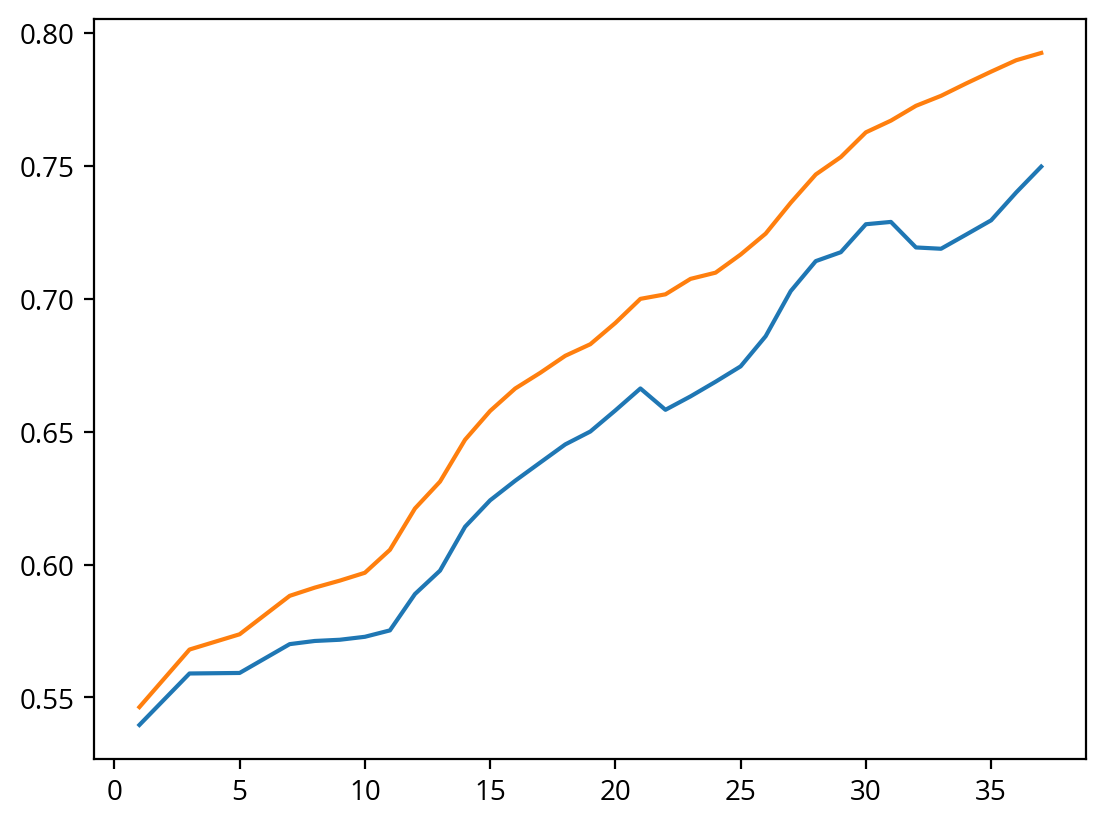

In [647]:
plt.plot(rep1_dg1_dom.groupby('alpha').mean().index, rep1_dg1_dom.groupby('alpha').mean().DG1_vs_MG1)
plt.plot(rep1_dg1_dom.groupby('alpha').mean().index, rep1_dg1_dom.groupby('alpha').mean().DG1_vs_postG1)

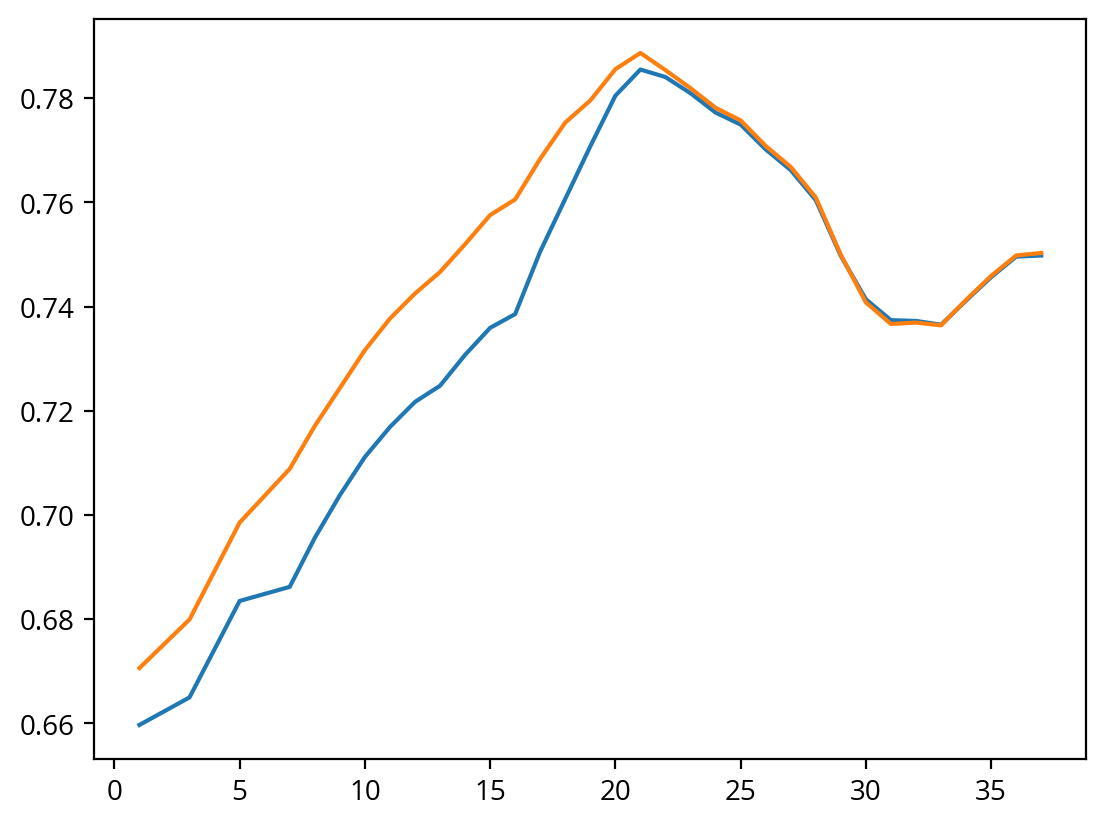

In [648]:
plt.plot(rep2_dg1_dom.groupby('alpha').mean().index, rep2_dg1_dom.groupby('alpha').mean().DG1_vs_MG1)
plt.plot(rep2_dg1_dom.groupby('alpha').mean().index, rep2_dg1_dom.groupby('alpha').mean().DG1_vs_postG1)

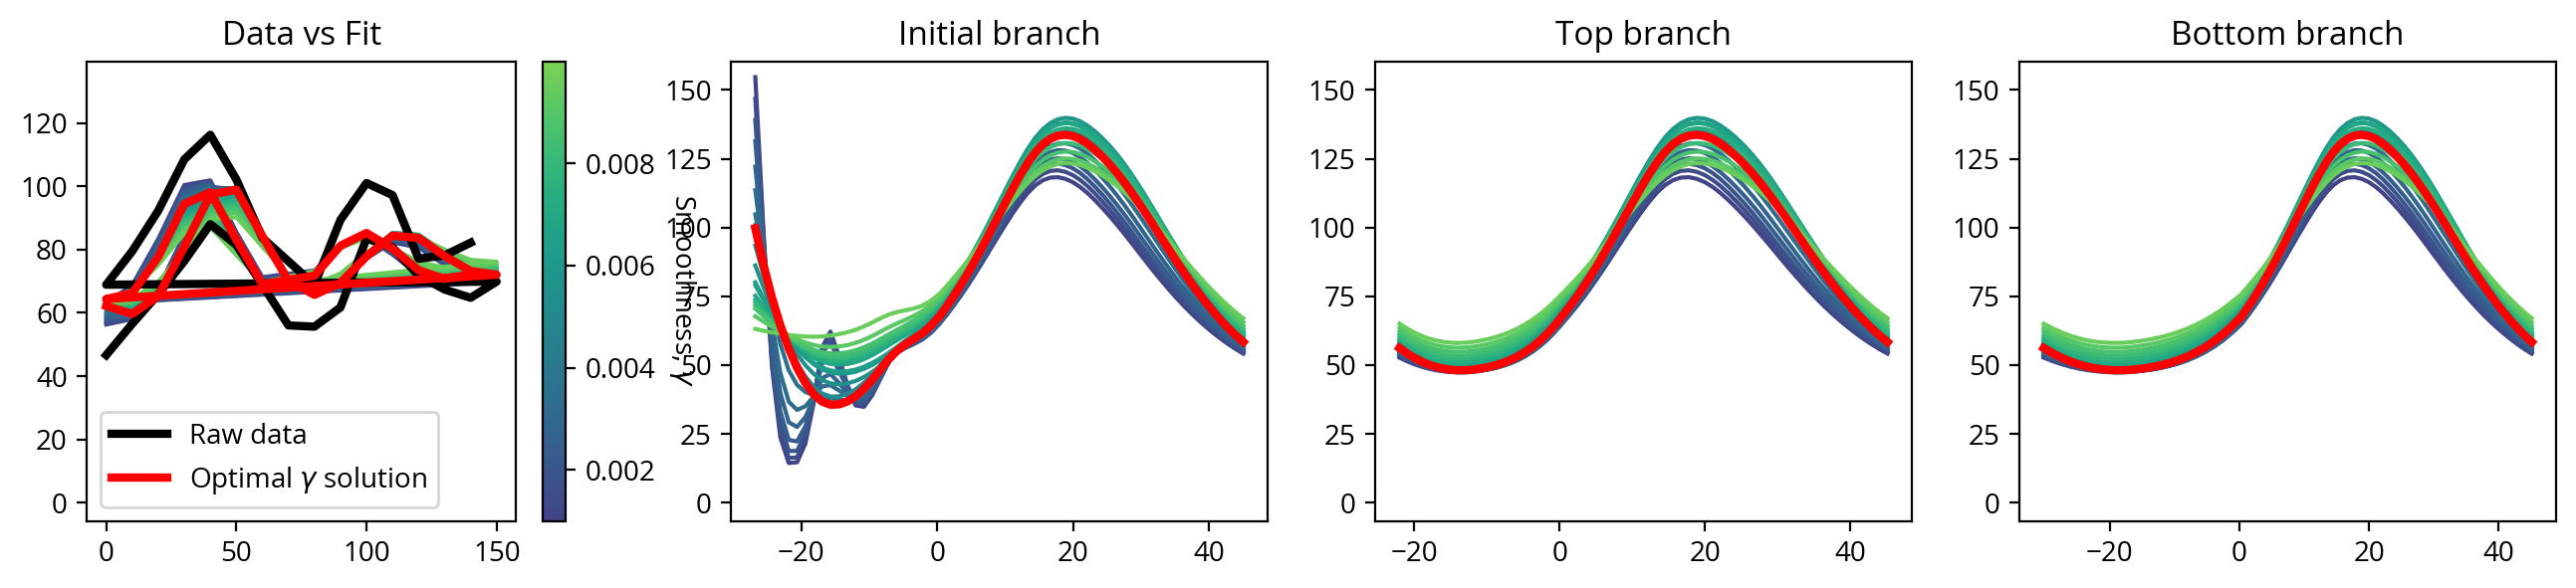

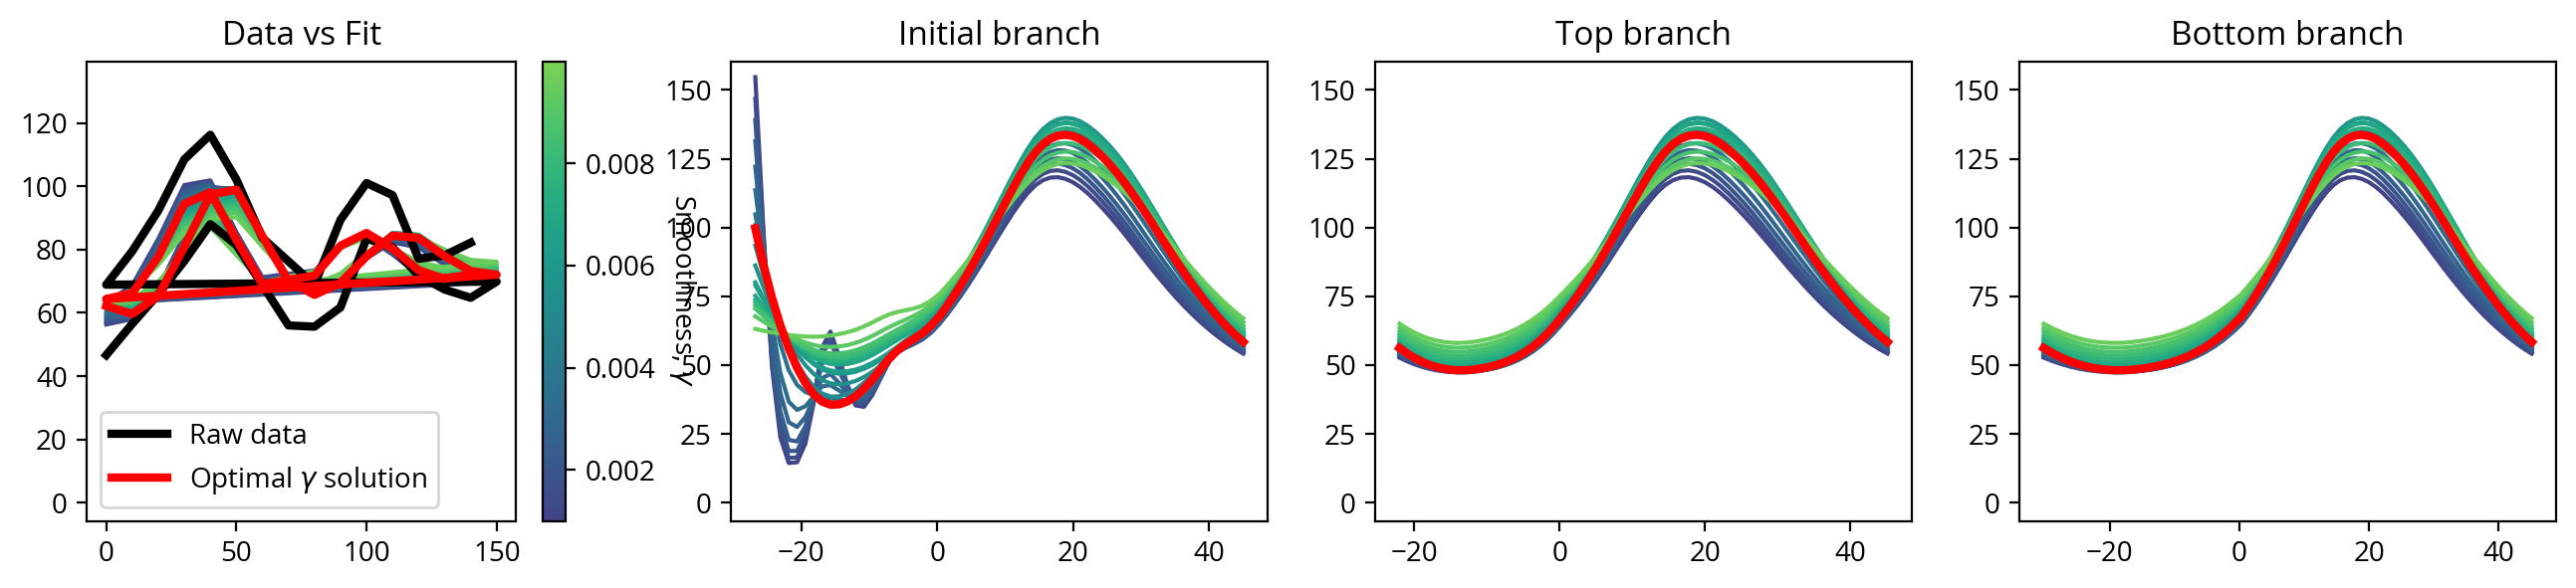

In [13]:
runner.deconvolve_gene('CDC14')
runner.expression_find_gamma.plot_gamma_sweep(plot_log_transform=False)

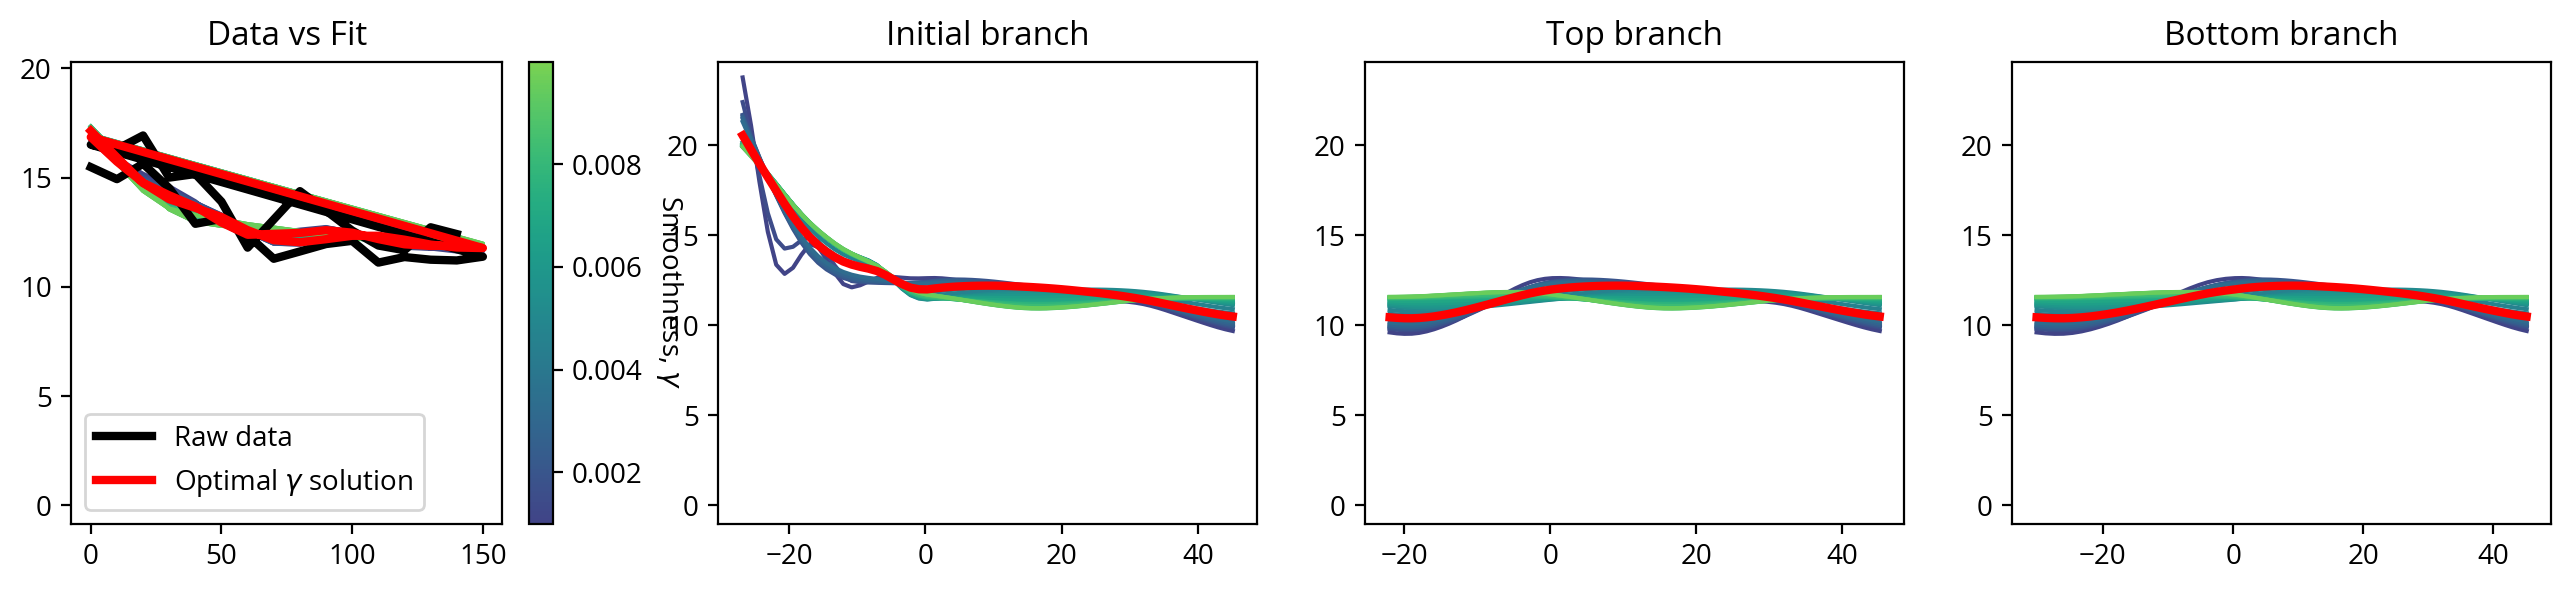

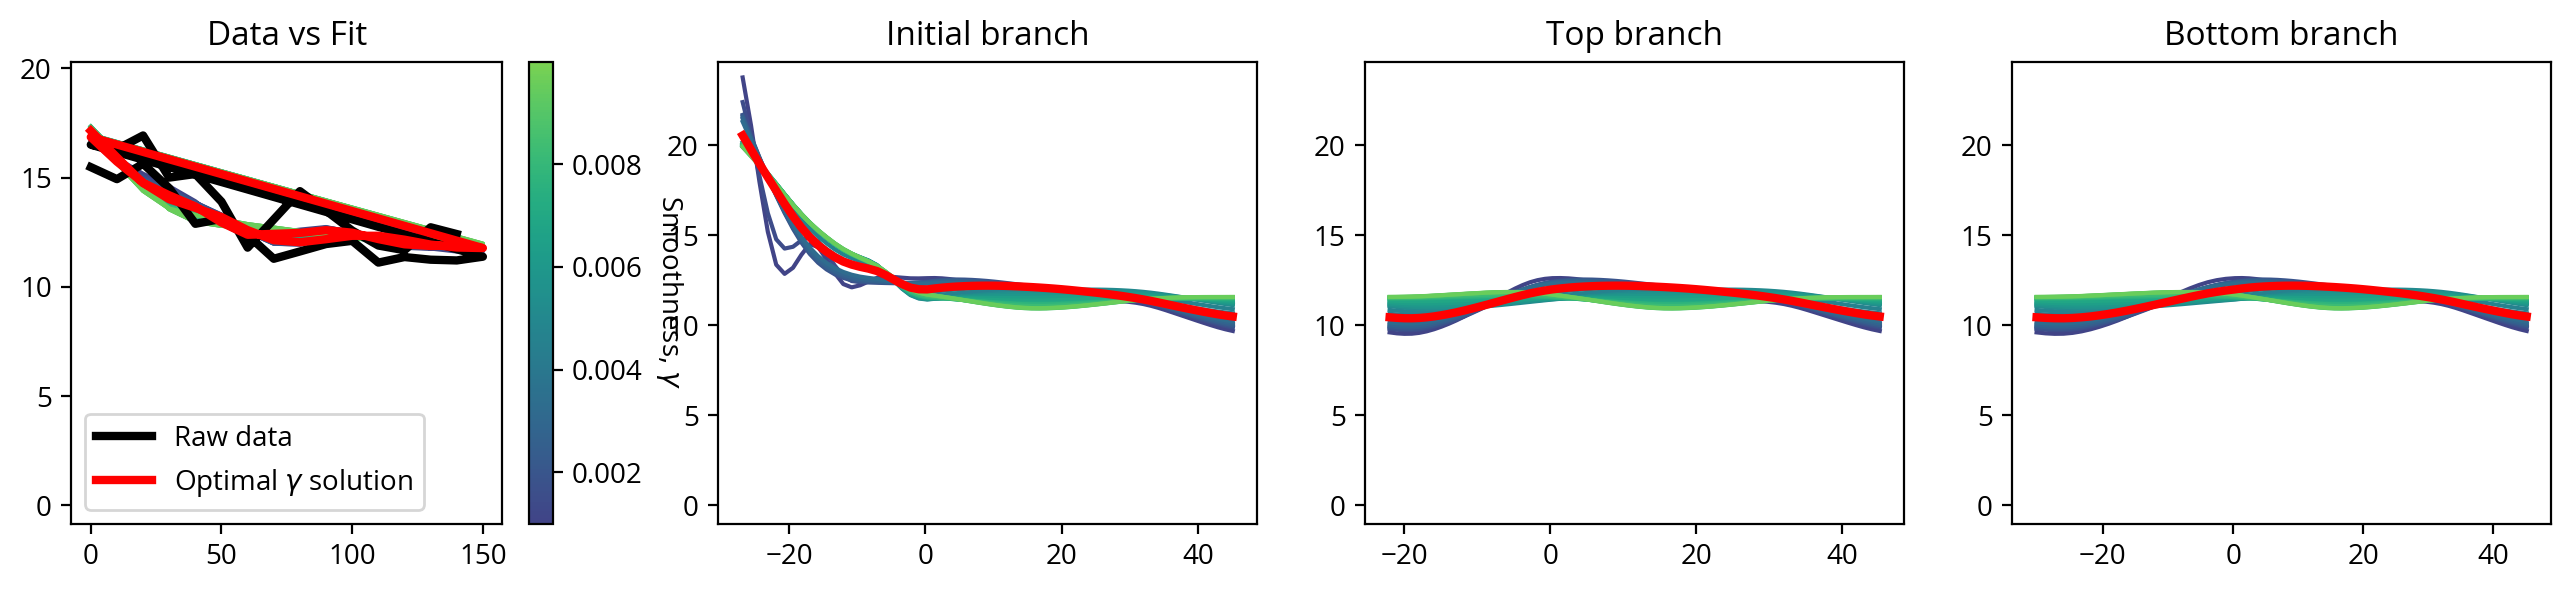

In [12]:
runner.deconvolve_gene('CDC15')
runner.expression_find_gamma.plot_gamma_sweep(plot_log_transform=False)

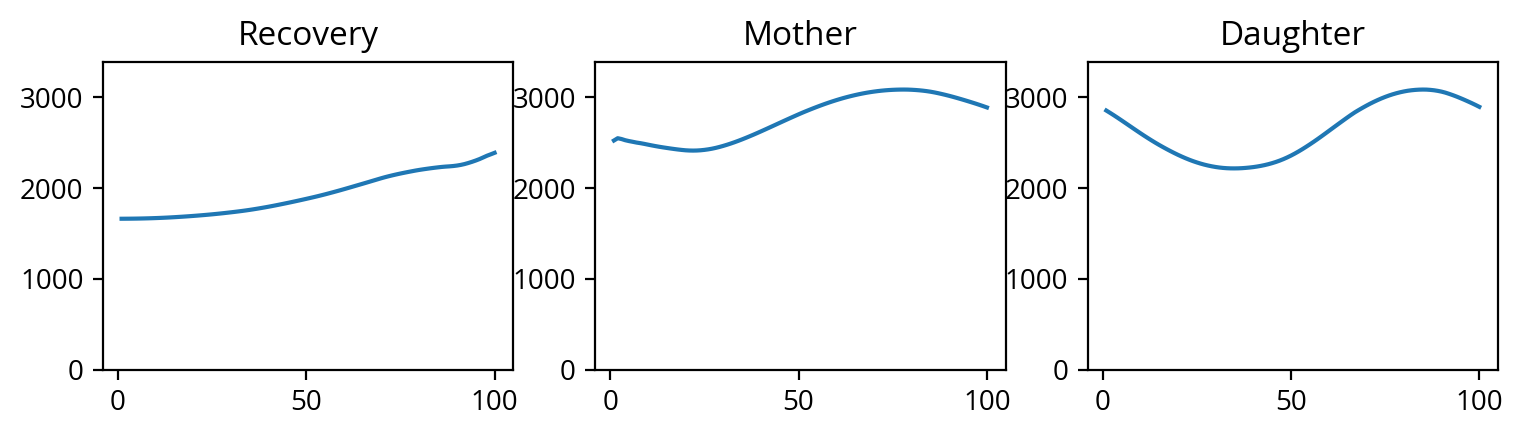

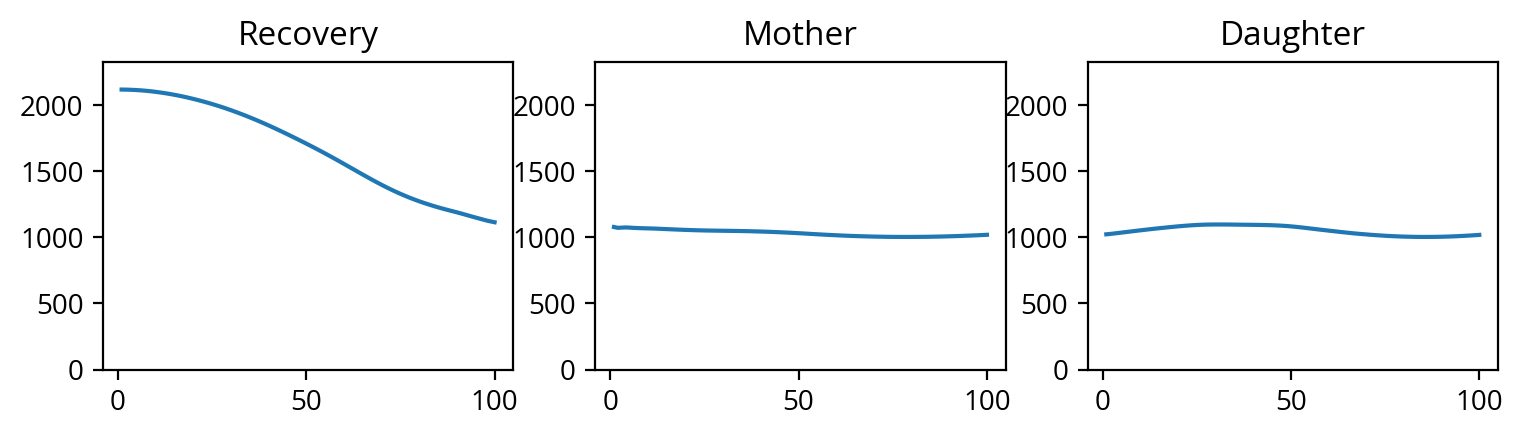

In [11]:
from src.reference_data import plot_guo_gene_expression
plot_guo_gene_expression('CDC14')
plot_guo_gene_expression('CDC15')